In [27]:
import numpy as np
import pandas as pd

np.random.seed(23)

# Class 1
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1','feature2','feature3'])
df['target'] = 1

# Class 2
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])
df1['target'] = 0

# Combine DataFrames
df = pd.concat([df, df1], ignore_index=True)

# Shuffle rows
df = df.sample(frac=1, random_state=23).reset_index(drop=True)

# First 5 rows
print(df.head())

   feature1  feature2  feature3  target
0 -0.331617 -1.632386  0.619114       1
1  1.010229  1.437830  2.327788       0
2  0.241106 -0.952510 -0.136267       1
3  1.676860  4.187503 -0.080565       0
4  2.823378 -0.332863  2.637391       0


In [28]:
import plotly.express as px
plt.figure(figsize=(3,4))
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

<Figure size 300x400 with 0 Axes>

In [29]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])
     

# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)
     


Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [30]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

     

In [31]:
eigen_values


array([1.3536065 , 0.94557084, 0.77774573])

In [32]:
eigen_vectors


array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

In [33]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch


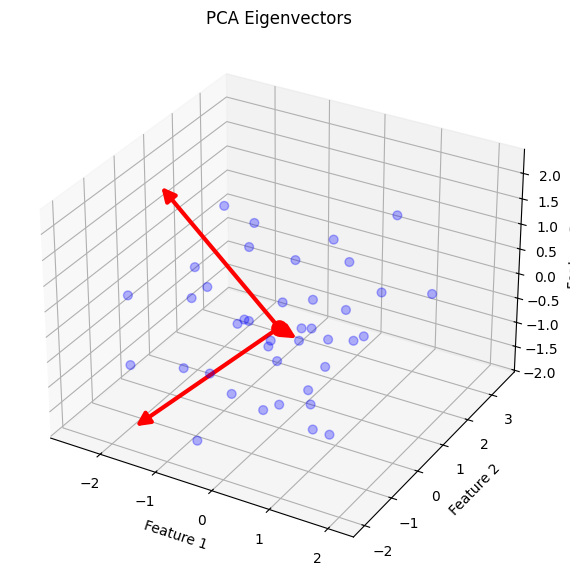

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d
import numpy as np

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(
            xs3d, ys3d, zs3d, self.axes.get_proj()
        )
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot data points
ax.scatter(
    df['feature1'],
    df['feature2'],
    df['feature3'],
    color='blue',
    alpha=0.3,
    s=40
)

# Mean point
mean = df[['feature1', 'feature2', 'feature3']].mean().values

ax.scatter(
    mean[0],
    mean[1],
    mean[2],
    color='red',
    s=120
)

# Scale eigenvectors for better visualization
scale = 3

for v in eigen_vectors.T:
    arrow = Arrow3D(
        [mean[0], mean[0] + scale * v[0]],
        [mean[1], mean[1] + scale * v[1]],
        [mean[2], mean[2] + scale * v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="red"
    )
    ax.add_artist(arrow)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_zlabel("Feature 3")
ax.set_title("PCA Eigenvectors")

plt.show()

In [35]:
# Sort eigenvalues and corresponding eigenvectors in descending order
idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# Select the first 2 principal components
pc = eigen_vectors[:, :2]

# Transform the original data (40x3) -> (40x2)
transformed_df = np.dot(df.iloc[:, :3], pc)

# Create a new DataFrame
new_df = pd.DataFrame(transformed_df, columns=['PC1', 'PC2'])
new_df['target'] = df['target'].values

# Display the first 5 rows
new_df.head()

,PC1,PC2,target
0,1.694055,0.454694,1
1,-1.654764,0.691473,0
2,1.349328,-0.377883,1
3,-2.572050,-1.265530,0
4,-1.544065,-0.194608,0


In [36]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()
     